# Analyzing the Autism Prevalence

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

Read csv files to Dataframe

In [4]:
# Read Prevalence Estimates by Race_Ethnicity
ethnicity = pd.read_csv("../data/Prevalence Estimates by Race_Ethnicity.csv")
ethnicity.head()

,Year,State,White,White Lower CI,White Upper CI,Black,Black Lower CI,Black Upper CI,Hispanic,Hispanic Lower CI,Hispanic Upper CI,Asian or Pacific Islander,Asian or Pacific Islander Lower CI,Asian or Pacific Islander Upper CI,American Indian or Alaska Native,American Indian or Alaska Native Lower CI,American Indian or Alaska Native Upper CI,Multiracial,Multiracial Lower CI,Multiracial Upper CI
0,2000,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,Arizona,8.6,7.5,9.8,7.3,4.4,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,Colorado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
ethnicity_year = ethnicity.groupby("Year")[["White","Black","Hispanic", "Asian or Pacific Islander","American Indian or Alaska Native","Multiracial"]].mean().reset_index()
ethnicity_year

,Year,White,Black,Hispanic,Asian or Pacific Islander,American Indian or Alaska Native,Multiracial
0,2000,7.283333,7.020000,NaN,NaN,NaN,NaN
1,2002,7.286667,5.753333,3.507692,4.709091,NaN,NaN
2,2004,8.155556,6.566667,5.587500,7.983333,NaN,NaN
3,2006,9.458333,7.450000,4.875000,6.660000,NaN,NaN
4,2008,14.573333,11.553333,7.806667,8.100000,NaN,NaN
5,2010,15.800000,11.600000,10.325000,11.400000,NaN,NaN
6,2012,15.833333,13.350000,10.100000,11.777778,NaN,NaN
7,2014,18.183333,16.300000,13.466667,13.433333,NaN,NaN
8,2016,19.308333,18.350000,14.133333,16.900000,NaN,NaN
9,2018,22.925000,23.809091,21.563636,21.860000,31.00,NaN


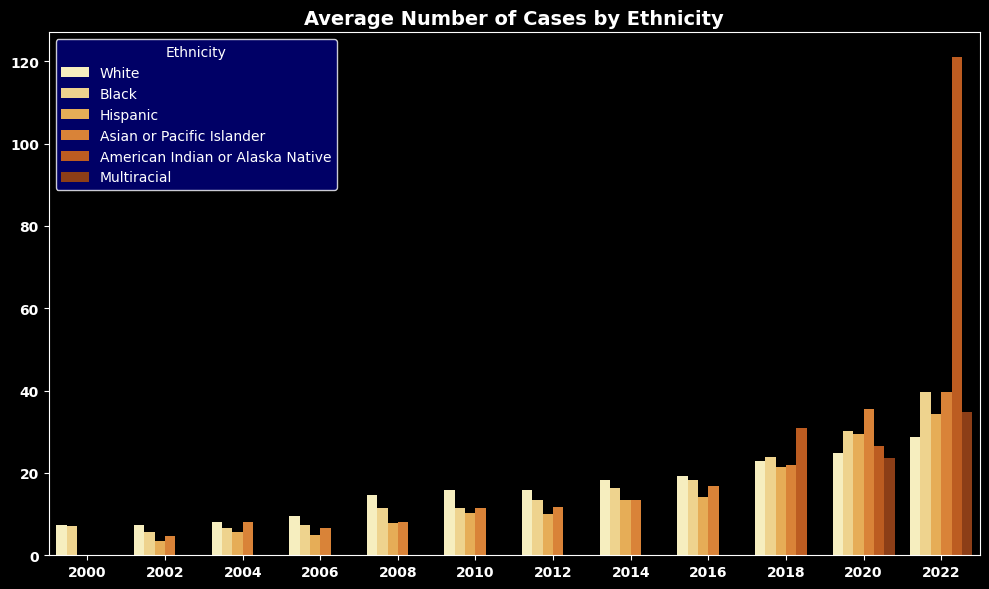

In [63]:
plt.figure(figsize=(10, 6), facecolor="black")

# Melt for easier plotting
ethnicity_melt = ethnicity_year.melt(id_vars="Year", value_vars=["White","Black","Hispanic", "Asian or Pacific Islander","American Indian or Alaska Native","Multiracial"],
                           var_name="Ethnicity", value_name="Count")


sns.barplot(
    data=ethnicity_melt,
    x="Year",
    y="Count",
    hue="Ethnicity",
    palette="YlOrBr"
)

# Title
plt.title(
    "Average Number of Cases by Ethnicity",
    fontsize=14,
    fontweight="bold",
    color="white"
)

# Axes styling
ax = plt.gca()
ax.set_facecolor("black")

# Tick labels
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

# Make legend title white
leg = plt.legend(title="Ethnicity",facecolor="navy", edgecolor="white", labelcolor="white")
plt.setp(leg.get_title(), color="white")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("cases_ethnicity", dpi=300, bbox_inches="tight", transparent=True)
plt.show()